In [18]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "pandas",
#     "polars",
#     "pyarrow",
#     "scikit-learn",
#     "seaborn",
# ]
# ///

In [19]:
from IPython.display import Markdown, display
from pathlib import Path

import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [20]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",   # math matches Times style
    "pdf.fonttype": 42,           # embed TrueType (Type 42), not Type 3
    "ps.fonttype": 42,
    "font.size": 9, "axes.titlesize": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

In [21]:
np.random.seed(42)

In [22]:
features = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",
    "Fwd Packet Length Std",
    "Bwd Packet Length Max",
    "Bwd Packet Length Min",
    "Bwd Packet Length Mean",
    "Bwd Packet Length Std",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Total",
    "Fwd IAT Mean",
    "Fwd IAT Std",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Bwd IAT Std",
    "Bwd IAT Max",
    "Bwd IAT Min",
    "Fwd PSH Flags",
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "Fwd RST Flags",
    "Bwd RST Flags",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Packet Length Min",
    "Packet Length Max",
    "Packet Length Mean",
    "Packet Length Std",
    "Packet Length Variance",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "URG Flag Count",
    "CWR Flag Count",
    "ECE Flag Count",
    "Down/Up Ratio",
    "Average Packet Size",
    "Fwd Segment Size Avg",
    "Bwd Segment Size Avg",
    "Fwd Bytes/Bulk Avg",
    "Fwd Packet/Bulk Avg",
    "Fwd Bulk Rate Avg",
    "Bwd Bytes/Bulk Avg",
    "Bwd Packet/Bulk Avg",
    "Bwd Bulk Rate Avg",
    "Subflow Fwd Packets",
    "Subflow Fwd Bytes",
    "Subflow Bwd Packets",
    "Subflow Bwd Bytes",
    "FWD Init Win Bytes",
    "Bwd Init Win Bytes",
    "Fwd Act Data Pkts",
    "Bwd Act Data Pkts",
    "Fwd Seg Size Min",
    "Bwd Seg Size Min",
    "Active Mean",
    "Active Std",
    "Active Max",
    "Active Min",
    "Idle Mean",
    "Idle Std",
    "Idle Max",
    "Idle Min",
    "Fwd TCP Retrans. Count",
    "Bwd TCP Retrans. Count",
    "Total TCP Retrans. Count",
    "Total Connection Flow Time",
]

In [23]:
df = pl.read_parquet("../data/samples/v1.1/mawiflow_samples_n1000_seed42_malicious_benign_balanced.parquet",
                     columns=["year", "taxonomy_norm"]+features)\
                        .to_pandas()

In [24]:
df.shape

(3441128, 86)

In [25]:
df.groupby(["year", "taxonomy_norm"]).size()\
    .reset_index(name="count")\
        .pivot(index="year", columns="taxonomy_norm", values="count")

taxonomy_norm,Alpha flow,DoS,HTTP,IPv6 tunneling,Multi. points,Network scan ICMP,Network scan TCP,Network scan UDP,Other,Port scan,Unknown,benign
year,,,,,,,,,,,,
2007,12000.0,10479.0,12000.0,2610.0,12000.0,12000.0,12000.0,12000.0,11232.0,8469.0,48.0,104838.0
2008,12000.0,11728.0,12000.0,2877.0,12000.0,12000.0,12000.0,12000.0,12000.0,11174.0,8.0,109787.0
2009,11917.0,10310.0,12000.0,7449.0,12000.0,12000.0,12000.0,12000.0,12000.0,7696.0,NaN,109372.0
2010,12000.0,10087.0,12000.0,12000.0,12000.0,11319.0,12000.0,12000.0,12000.0,8350.0,NaN,113756.0
2011,12000.0,10217.0,12000.0,12000.0,12000.0,8485.0,12000.0,12000.0,10465.0,4937.0,NaN,106104.0
2012,12000.0,11000.0,12000.0,9231.0,12000.0,12000.0,12000.0,12000.0,11651.0,10750.0,3004.0,117636.0
2013,12000.0,8617.0,12000.0,662.0,12000.0,8000.0,12000.0,12000.0,12000.0,10084.0,4015.0,103378.0
2014,12000.0,12000.0,12000.0,1937.0,12000.0,2254.0,12000.0,12000.0,9755.0,8129.0,265.0,94340.0
2015,12000.0,12000.0,12000.0,3168.0,12000.0,4904.0,12000.0,12000.0,12000.0,6954.0,2530.0,101556.0


In [26]:
scaler = StandardScaler().fit(df[features])
df[features] = scaler.transform(df[features])

In [27]:
years = df["year"].unique()
first_year = years.min()

print(f"{first_year=}")
years

first_year=np.int64(2007)


array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [28]:
taxonomies = df["taxonomy_norm"].unique()
taxonomies

array(['HTTP', 'benign', 'Network scan ICMP', 'Multi. points',
       'Alpha flow', 'Network scan TCP', 'Network scan UDP', 'DoS',
       'Port scan', 'Other', 'IPv6 tunneling', 'Unknown'], dtype=object)

In [29]:
pca = PCA(n_components=2).fit(df.query("year == @first_year")[features])

In [30]:
pcs = pca.transform(df[features])
pc_cols = [f"PCA{i+1}" for i in range(pcs.shape[1])]
df[pc_cols] = pcs

In [31]:
sub = df.query("year in [2014, 2015, 2016]").copy()

In [ ]:
def plot_boxhist(df, fig_path=None):
    fig = plt.figure(figsize=(3, 3), constrained_layout=True)
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 3])

    ax_box  = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharex=ax_box)

    years = sorted(df['year'].unique())
    base_colors = sns.color_palette(n_colors=len(years))
    year_palette = dict(zip(years, base_colors))

    sns.boxplot(
        data=df,
        x="PCA1",
        y="year",
        hue="year",
        orient="h",
        fliersize=2,
        order=years,
        palette=year_palette,
        legend=False,
        ax=ax_box
    )
    ax_box.set(xlabel="", ylabel="")

    sns.histplot(
        data=df,
        x="PCA1",
        hue="year",
        stat="proportion",
        common_norm=False,
        element="step",
        fill=False,
        bins=20,
        multiple="layer",
        palette=year_palette,
        ax=ax_hist
    )
    ax_hist.legend_.set_title("Year")
    ax_hist.set(xlabel="PCA Dimension 1", ylabel="Proportion")

    if fig_path:
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

## All flows

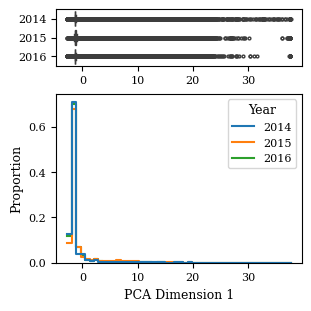

In [33]:
plot_boxhist(sub)

## Taxonomy: HTTP

PC1 loadings


Active Mean      0.577484
Active Min       0.571633
Active Max       0.517020
Active Std       0.185206
Flow Duration    0.115980
dtype: float64

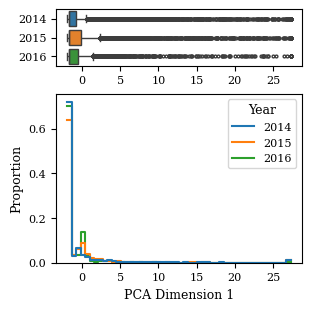

## Taxonomy: benign

PC1 loadings


Down/Up Ratio    0.999918
Bwd IAT Max      0.007225
Idle Min         0.004654
Idle Mean        0.004473
Flow IAT Max     0.004109
dtype: float64

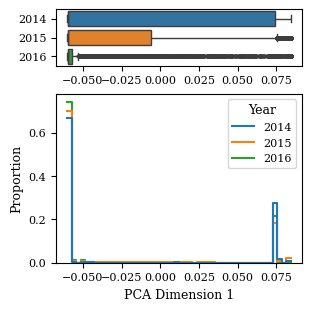

## Taxonomy: Network scan ICMP

PC1 loadings


Bwd IAT Mean    0.310882
Bwd IAT Min     0.294201
Fwd IAT Mean    0.281660
Fwd IAT Min     0.278244
Bwd IAT Max     0.273450
dtype: float64

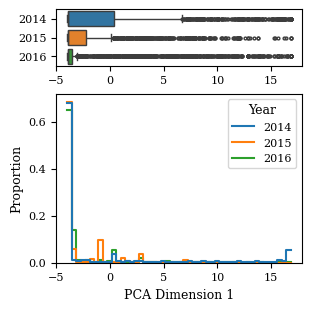

## Taxonomy: Multi. points

PC1 loadings


FIN Flag Count                0.949526
Flow Duration                 0.082259
Fwd IAT Total                 0.082011
Total Connection Flow Time    0.073797
Bwd IAT Total                 0.071067
dtype: float64

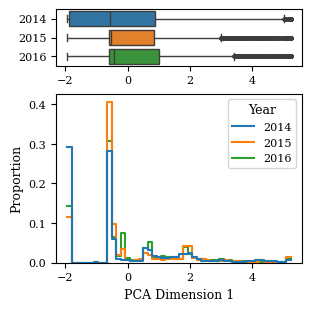

## Taxonomy: Alpha flow

PC1 loadings


Fwd PSH Flags                 0.731758
PSH Flag Count                0.673677
ACK Flag Count                0.084334
Total Connection Flow Time    0.027912
Fwd IAT Total                 0.021502
dtype: float64

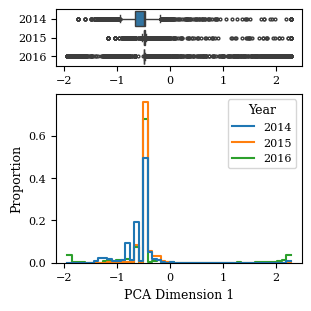

## Taxonomy: Network scan TCP

PC1 loadings


Bwd IAT Max      0.377728
Bwd IAT Std      0.365225
Bwd IAT Total    0.314479
Flow IAT Max     0.270728
Idle Max         0.269840
dtype: float64

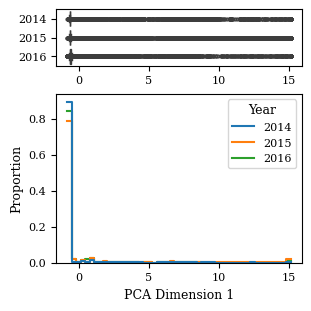

## Taxonomy: Network scan UDP

PC1 loadings


Bwd Packet/Bulk Avg       0.700985
Bwd Bytes/Bulk Avg        0.687652
Fwd Bulk Rate Avg         0.119869
Bwd Packet Length Min     0.061094
Bwd Packet Length Mean    0.061053
dtype: float64

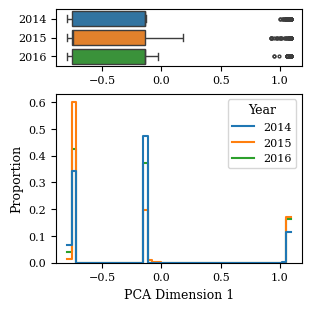

## Taxonomy: DoS

PC1 loadings


SYN Flag Count    0.746547
Active Min        0.213302
Fwd IAT Max       0.204187
Idle Min          0.201304
Idle Mean         0.199489
dtype: float64

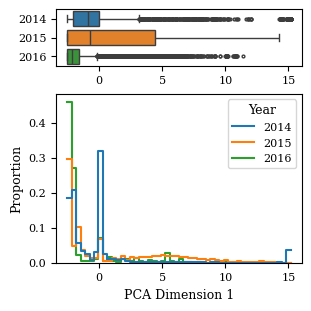

## Taxonomy: Port scan

PC1 loadings


Packet Length Min        0.359835
Fwd Packet Length Min    0.359822
Packet Length Mean       0.350469
Average Packet Size      0.350469
Fwd Segment Size Avg     0.350469
dtype: float64

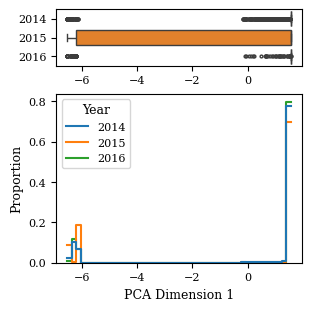

## Taxonomy: Other

PC1 loadings


Fwd IAT Min     0.334620
Fwd IAT Mean    0.330970
Bwd IAT Min     0.284239
Bwd IAT Mean    0.274149
Idle Min        0.272830
dtype: float64

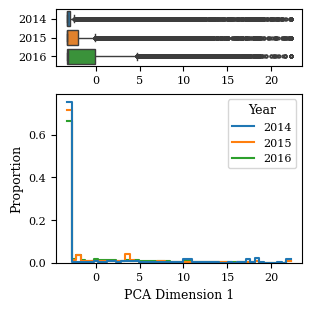

## Taxonomy: IPv6 tunneling

PC1 loadings


Bwd IAT Total       0.753992
Fwd IAT Total       0.376480
Flow Duration       0.356232
Total Fwd Packet    0.169276
Active Max         -0.132222
dtype: float64

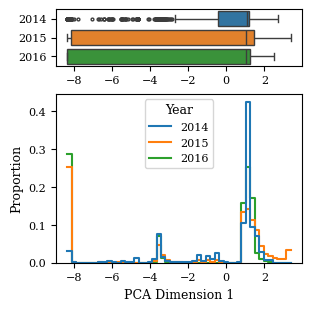

## Taxonomy: Unknown

PC1 loadings


Active Std       0.587150
Active Max       0.496185
Fwd IAT Total    0.338266
Flow Duration    0.328805
Active Mean      0.287188
dtype: float64

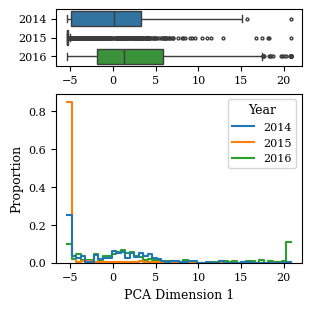

In [36]:
fig_dir = Path("../results/pca_drift/")
fig_dir.mkdir(parents=True, exist_ok=True)

for taxonomy in taxonomies:
    display(Markdown(f"## Taxonomy: {taxonomy}"))

    tax = sub.query("taxonomy_norm == @taxonomy").copy()
    first_year = tax["year"].min()

    pca = PCA(n_components=2).fit(tax.query("year == @first_year")[features])
    tax["PCA1"], tax["PCA2"] = pca.transform(tax[features]).T

    q1 = tax["PCA1"].quantile(0.01)
    q99 = tax["PCA1"].quantile(0.99)
    tax["PCA1"] = tax["PCA1"].clip(lower=q1, upper=q99)

    loadings_pc1 = pca.components_[0]
    pc1_loadings = pd.Series(loadings_pc1, index=features).sort_values(key=abs, ascending=False)
    print("PC1 loadings")
    display(pc1_loadings.head(5))

    plot_boxhist(tax, fig_path = fig_dir / f"pca-drift-{taxonomy}.pdf")